# 01.1. Comparación de encoders

La indexación convierte los artículos en vectores para poder buscarlos. El encoder hace esa representación. El decoder redacta la respuesta después.

Se comparan primero los tres encoders recomendados. E5-base queda como alternativa más pequeña. Se usan los mismos artículos y sondas en todas las corridas.

Usar el kernel AI Week y ejecutar las celdas en orden. Los modelos ya están descargados en este equipo. Esta comparación se corre sola, sin ejecutar el notebook de decoders al mismo tiempo.

In [1]:
from pathlib import Path
import json
import sys
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

raiz = Path.cwd()
if not (raiz / "configs").exists():
    raiz = raiz.parent
catalogo = json.loads((raiz / "configs/modelos.json").read_text(encoding="utf-8"))
pd.DataFrame(catalogo["encoders"])[["nombre", "parametros", "licencia", "contexto_tokens", "recomendado"]]

,nombre,parametros,licencia,contexto_tokens,recomendado
0,multilingual-e5-large,559890432,mit,512,True
1,bge-m3,567754752,mit,8192,True
2,jina-embeddings-v3,572310396,cc-by-nc-4.0,8192,True
3,multilingual-e5-base,278043648,mit,512,False


## Comparación

Los tamaños son 192, 320 y 448 tokens. El solapamiento es de 32. Las ventanas sirven para buscar y luego se devuelve el artículo completo. No se cortan los artículos que se usan como evidencia.

Las consultas salen del número y título de la norma o de un extracto literal. Esto mide recuperación. No mide si el sistema resuelve un caso jurídico.

In [2]:
modelos = ["multilingual-e5-large", "bge-m3", "jina-embeddings-v3", "multilingual-e5-base"]
tamanos = [192, 320, 448]

comando = [sys.executable, "-u", "scripts/comparar_encoders.py",
           "--modelos", *modelos, "--tamanos", *map(str, tamanos)]
proceso = subprocess.Popen(comando, cwd=raiz, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
try:
    for linea in proceso.stdout:
        print(linea, end="", flush=True)
    if proceso.wait():
        raise RuntimeError("La comparación terminó con error. Revisar la salida anterior.")
finally:
    if proceso.poll() is None:
        proceso.terminate()
        proceso.wait()

Muestra: 555 artículos, 54 sondas
Cargando multilingual-e5-large
{"modelo": "multilingual-e5-large", "recomendado": true, "tamano_tokens": 192, "metodo": "denso", "sondas": 54, "recall_1": 0.9074074074074074, "recall_5": 0.9629629629629629, "recall_10": 0.9814814814814815, "mrr_10": 0.9270282186948855, "consulta_mediana_s": 0.054505000001881854, "consulta_p95_s": 0.08283162499992612, "carga_s": 27.845871399997122, "segundos": 20.053737700000056, "ventanas": 959, "unidades": 555, "vram_pico_mib": 1126.78125, "ram_rss_mib": 2112.671875, "sha256_indice": "a74dee9573e9e3c6086b18ebc1732bd83014b000e049924cd3835b252d560d28"}
{"modelo": "multilingual-e5-large", "recomendado": true, "tamano_tokens": 192, "metodo": "hibrido", "sondas": 54, "recall_1": 0.9259259259259259, "recall_5": 1.0, "recall_10": 1.0, "mrr_10": 0.9598765432098766, "consulta_mediana_s": 0.07878809999783698, "consulta_p95_s": 0.10073428000105195, "carga_s": 27.845871399997122, "segundos": 20.053737700000056, "ventanas": 959, "

## Resultados medidos

La tabla incluye búsqueda densa e híbrida. Las dos gráficas muestran solo la búsqueda densa para comparar los encoders con el mismo método.

In [3]:
ejecucion = json.loads((raiz / "reports/f_encoders_ultima.json").read_text(encoding="utf-8"))
assert ejecucion["estado"] == "completo"
carpeta = raiz / ejecucion["reportes"]
filas = [json.loads(p.read_text(encoding="utf-8"))
         for p in sorted(carpeta.glob("f_encoder_*.json"))]
resultados = pd.DataFrame(filas)
resultados[["modelo", "tamano_tokens", "metodo", "sondas", "recall_1", "recall_5", "recall_10", "mrr_10", "consulta_mediana_s", "vram_pico_mib"]]

,modelo,tamano_tokens,metodo,sondas,recall_1,recall_5,recall_10,mrr_10,consulta_mediana_s,vram_pico_mib
0,bge-m3,192,denso,54,0.833333,0.962963,0.981481,0.889660,0.058539,1140.797852
1,bge-m3,192,hibrido,54,0.925926,0.981481,1.000000,0.952160,0.073808,1140.797852
2,bge-m3,320,denso,54,0.851852,0.981481,1.000000,0.902954,0.058100,1165.757324
3,bge-m3,320,hibrido,54,0.925926,1.000000,1.000000,0.952160,0.070838,1165.757324
4,bge-m3,448,denso,54,0.851852,0.962963,0.981481,0.894621,0.052557,1198.103516
5,bge-m3,448,hibrido,54,0.888889,0.981481,1.000000,0.929012,0.068831,1198.103516
6,jina-embeddings-v3,192,denso,54,0.703704,0.907407,0.981481,0.800485,0.273304,2106.586426
7,jina-embeddings-v3,192,hibrido,54,0.888889,1.000000,1.000000,0.941358,0.291902,2106.586426
8,jina-embeddings-v3,320,denso,54,0.666667,0.888889,0.962963,0.771495,0.281933,2108.547852
9,jina-embeddings-v3,320,hibrido,54,0.777778,0.981481,1.000000,0.876102,0.284868,2108.547852


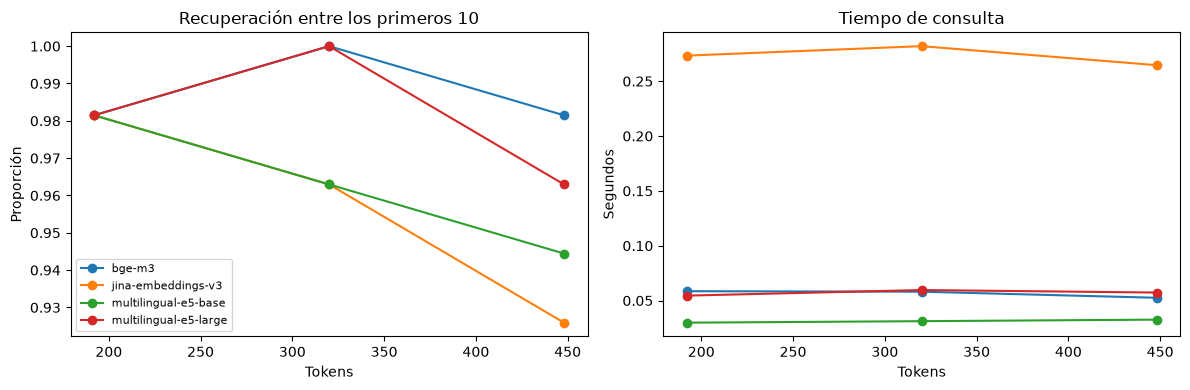

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, grupo in resultados[resultados.metodo == "denso"].groupby("modelo"):
    grupo = grupo.sort_values("tamano_tokens")
    ejes[0].plot(grupo.tamano_tokens, grupo.recall_10, marker="o", label=nombre)
    ejes[1].plot(grupo.tamano_tokens, grupo.consulta_mediana_s, marker="o", label=nombre)
ejes[0].set(title="Recuperación entre los primeros 10", xlabel="Tokens", ylabel="Proporción")
ejes[1].set(title="Tiempo de consulta", xlabel="Tokens", ylabel="Segundos")
ejes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## Resultados

Estos resultados corresponden a la ejecución guardada del 27 de septiembre. Si se repite la prueba o se cambian los parámetros, las tablas se actualizan y estas conclusiones se revisan con los nuevos datos.

Se compararon 24 combinaciones sobre 555 artículos de 142 normas. Las 54 sondas consultan 27 artículos de 26 normas y diez áreas.

E5-large híbrido de 192 tokens obtuvo el MRR máximo, 0,9599. Con 320 obtuvo 0,9583 y el mismo recall, 50 de 54 sondas en primer puesto y 54 de 54 entre los primeros cinco. Usa 713 ventanas frente a 959 y recupera primero los cuatro casos de los artículos 24 y 42.

Con 320, la consulta mediana fue 75,75 ms y el p95 fue 100,05 ms. El pico de VRAM durante la construcción densa fue 1151,81 MiB. El RSS al terminar fue 2136,78 MiB y no representa un pico de RAM.

## Decisiones

- Empezar con E5-large híbrido de 320 tokens y solapamiento de 32. Conservar 192 como alternativa.
- El experimento usó batch 4. La construcción completa usará batch 16 y deberá medir de nuevo memoria y latencia.
- Verificar las mismas sondas sobre todo el índice después de la corrección de orden de BM25. Conservar estas mediciones originales.
- Tratar estos resultados como pruebas de localización. No miden exactitud jurídica ni un puntaje oficial.
